<a href="https://colab.research.google.com/github/hanbiphyun/ESSA_YB/blob/main/ESAA_OB_week2_2_%ED%95%84%EC%82%AC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##파이썬 머신러닝 완벽가이드

8장 텍스트 분석 p.566~583
###10. 텍스트 분석 실습 - 캐글 Mercari Price Suggestion Challenge

: 일본의 대형 온라인 쇼핑몰인 Mercari사의 제품에 대해 가격 예측하는 과제
- 데이터 : 제품에 대한 여러 속성 및 제품 설명 등의 텍스트 데이터
- 제품명, 브랜드명, 카테고리, 제품 설명 등 속성 정보 -> 예측 가격 제공

**데이터 속성**
- train_id： 데이터 id
- name： 제품명
- item_condition_id： 판매자가 제공하는 제품 상태
- category_name： 카테고리 명
- brand_name： 브랜드 이름
- price： 제품 가격. 예측을 위한 타깃 속성
- shipping： 배송비 무료 여부. 1 이면 무료(판매자가 지불), 0이면 유료(구매자 지불)
- item_description： 제품에 대한 설명

-> price 예측 타깃, 회귀로 피처 학습한 예측, 텍스트 형태의 비정형 데이터와 다른 정형 속성을 같이 적용해서 회귀 수행


###1. 데이터 전처리

In [7]:
# !7z x "압축파일명.7z"
!7z x train.tsv.7z


7-Zip [64] 16.02 : Copyright (c) 1999-2016 Igor Pavlov : 2016-05-21
p7zip Version 16.02 (locale=en_US.UTF-8,Utf16=on,HugeFiles=on,64 bits,2 CPUs Intel(R) Xeon(R) CPU @ 2.20GHz (406F0),ASM,AES-NI)

Scanning the drive for archives:
  0M Scan         1 file, 77912192 bytes (75 MiB)

Extracting archive: train.tsv.7z
--
Path = train.tsv.7z
Type = 7z
Physical Size = 77912192
Headers Size = 122
Method = LZMA2:24
Solid = -
Blocks = 1

  0%      3% - train.tsv                  7% - train.tsv                 10% - train.tsv                 13% - train.tsv                 17% - train.tsv                 21% - train.tsv                 23% - train.tsv                 27% - train.tsv                 30% - train.tsv

In [8]:
from sklearn.linear_model import Ridge, LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
import pandas as pd

mercari_df= pd.read_csv('/content/train.tsv', sep='\t')
print(mercari_df.shape)
mercari_df.head(3)

(1482535, 8)


,train_id,name,item_condition_id,category_name,brand_name,price,shipping,item_description
0,0,MLB Cincinnati Reds T Shirt Size XL,3,Men/Tops/T-shirts,NaN,10.0,1,No description yet
1,1,Razer BlackWidow Chroma Keyboard,3,Electronics/Computers & Tablets/Components & P...,Razer,52.0,0,This keyboard is in great condition and works ...
2,2,AVA-VIV Blouse,1,Women/Tops & Blouses/Blouse,Target,10.0,1,Adorable top with a hint of lace and a key hol...


피처 타입과 Null 여부 확인

In [9]:
print(mercari_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1482535 entries, 0 to 1482534
Data columns (total 8 columns):
 #   Column             Non-Null Count    Dtype  
---  ------             --------------    -----  
 0   train_id           1482535 non-null  int64  
 1   name               1482535 non-null  object 
 2   item_condition_id  1482535 non-null  int64  
 3   category_name      1476208 non-null  object 
 4   brand_name         849853 non-null   object 
 5   price              1482535 non-null  float64
 6   shipping           1482535 non-null  int64  
 7   item_description   1482529 non-null  object 
dtypes: float64(1), int64(3), object(4)
memory usage: 90.5+ MB
None


target칼럼인 가격 컬럼의 분포 확인

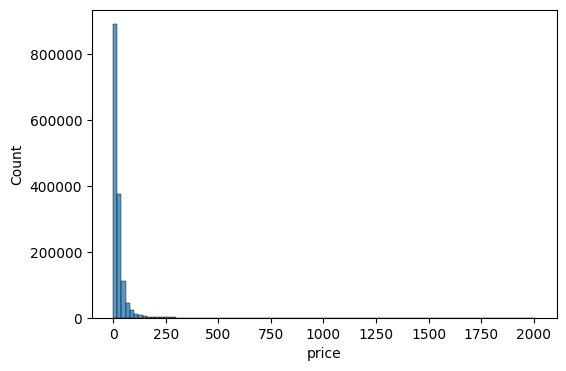

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

y_train_df= mercari_df['price']
plt.figure(figsize=(6,4))
sns.histplot(y_train_df, bins=100)
plt.show()

로그 변환

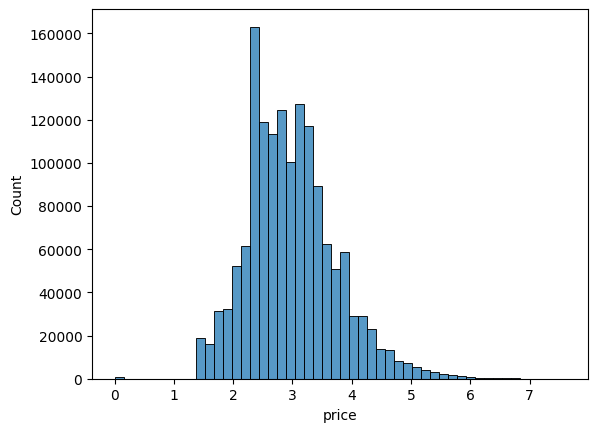

In [11]:
import numpy as np

y_train_df= np.log1p(y_train_df)
sns.histplot(y_train_df, bins=50)
plt.show()

이제 데이터 세트 price 칼럼을 로그변환한 값으로 변경

In [12]:
mercari_df['price']=np.log1p(mercari_df['price'])
mercari_df['price'].head(3)

,price
0,2.397895
1,3.970292
2,2.397895


shipping, item_condition_id 유형

In [13]:
print('Shipping 값 유형:\n', mercari_df['shipping'].value_counts())
print('item_condition_id 값 유형:\n', mercari_df['item_condition_id'].value_counts())

Shipping 값 유형:
 shipping
0    819435
1    663100
Name: count, dtype: int64
item_condition_id 값 유형:
 item_condition_id
1    640549
3    432161
2    375479
4     31962
5      2384
Name: count, dtype: int64


In [14]:
boolean_cond= mercari_df['item_description']=='No description yet'
mercari_df[boolean_cond]['item_description'].count()

np.int64(82489)

설명이 없는 행이 82439건, 의미 있는 속성값은 아니니 변경 필요.

- category_name 피처
  - /로 분리된 카테고리로 이루어짐
  -> /를 기준으로 단어 토큰화하여 각각 별로의 피처로 저장해 알고리즘 학습시키자
  - 대, 중, 소분류를 효과적으로 하기 위해 split_cat() 함수생성 후 DataFrame의 apply lambda 식에 적용하자

In [15]:
# apply lambda에서 호출되는 대, 중, 소 분할 함수생성, 대, 중, 소 값을 리스트로 반환
def split_cat(category_name):
  try:
    return category_name.split('/')
  except:
    return ['Other_Null', 'Other_Null', 'Other_Null']

# 위의 split_cat()을 apply lambda에서 호출해 대, 중, 소 칼럼을 mercari_df에 생성
mercari_df['cat_dae'], mercari_df['cat_jung'], mercari_df['cat_so'] = \
zip(*mercari_df['category_name'].apply(lambda x : split_cat(x)))

#대분류만 값의 유형과 건수를 살펴보고, 중분류, 소분류는 값의 유형이 많으므로 분류 개수만 추출
print('대분류 유형:\n', mercari_df['cat_dae'].value_counts())
print('중분류 유형:\n', mercari_df['cat_jung'].nunique())
print('소분류 유형:\n', mercari_df['cat_so'].nunique())

대분류 유형:
 cat_dae
Women                     664385
Beauty                    207828
Kids                      171689
Electronics               122690
Men                        93680
Home                       67871
Vintage & Collectibles     46530
Other                      45351
Handmade                   30842
Sports & Outdoors          25342
Other_Null                  6327
Name: count, dtype: int64
중분류 유형:
 114
소분류 유형:
 871


브랜드명, 카테고리 이름, 상품설명 칼럼의 Null값은 Other Null로 변경하자
- fillna() 적용

In [16]:
mercari_df['brand_name']= mercari_df['brand_name'].fillna(value='Other_Null')
mercari_df['category_name']= mercari_df['category_name'].fillna(value='Other_Null')
mercari_df['item_description']= mercari_df['item_description'].fillna(value='Other_Null')

# 각 칼럼별로 Null 값 건수 확인. 모두 0이 나와야합니다.
mercari_df.isnull().sum()

,0
train_id,0
name,0
item_condition_id,0
category_name,0
brand_name,0
price,0
shipping,0
item_description,0
cat_dae,0
cat_jung,0


**피처 인코딩과 피처 벡터화**
- 칼럼을 숫자형으로 인코딩 & 텍스트형 칼럼에 대해 피처 벡터화 적용
- 인코딩 피처는 모두 원-핫인코딩
- 벡터화 : 짧은 텍스트는 Count 기반, 긴 텍스트는 TD-IDF기반

먼저 brand_name검토해보자

In [17]:
print('brand name 의 유형 건수 ：', mercari_df['brand_name'].nunique())
print('brand name sample 5건 : \n', mercari_df['brand_name'].value_counts()[:5])

brand name 의 유형 건수 ： 4810
brand name sample 5건 : 
 brand_name
Other_Null           632682
PINK                  54088
Nike                  54043
Victoria's Secret     48036
LuLaRoe               31024
Name: count, dtype: int64


- 명료한 문자열이니 인코딩 변환만 하자
- 종류가 많긴 한데 그냥 원핫인코딩으로!

In [18]:
print('name 의 종류 개수 ：', mercari_df['name'].nunique())
print('name sample 7건: \n', mercari_df['name'][:7])

name 의 종류 개수 ： 1225273
name sample 7건: 
 0    MLB Cincinnati Reds T Shirt Size XL
1       Razer BlackWidow Chroma Keyboard
2                         AVA-VIV Blouse
3                  Leather Horse Statues
4                   24K GOLD plated rose
5       Bundled items requested for Ruie
6     Acacia pacific tides santorini top
Name: name, dtype: object


- 전체 데이터 행 개수만큼 종류 가짐 -> 고유한 상품명 가짐
- Count 기반으로 피처 벡터화 변환 적용하자

- category_name은 이전에 분류 3 칼럼으로 분리했으니 각각 원핫인코딩하자
- Shipping칼럼(0,1)과 item_condition_id(1,2,3,4,5)는 원핫인코딩하자

item_description 살펴보자
- 평균 문자열이 145자이므로 TF-IDF변환하자

In [19]:
pd.set_option('max_colwidth', 200)

#item_description의 평균 문자열 크기
print('item_description 평균 문자열 크기:', mercari_df['item_description'].str.len().mean())

mercari_df['item_description'][:2]

item_description 평균 문자열 크기: 145.71139703278507


,item_description
0,No description yet
1,This keyboard is in great condition and works like it came out of the box. All of the ports are tested and work perfectly. The lights are customizable via the Razer Synapse app on your PC.


In [20]:
# name속성에 대한 피처 벡터화 변환
cnt_vec= CountVectorizer()
X_name= cnt_vec.fit_transform(mercari_df.name)

# item_description에 대한 피처 벡터화 변환
tfidf_descp= TfidfVectorizer(max_features=50000, ngram_range=(1,3), stop_words='english')
X_descp= tfidf_descp.fit_transform(mercari_df['item_description'])

print('name vectorization shape:', X_name.shape)
print('item_description vectorization shape:', X_descp.shape)

name vectorization shape: (1482535, 105757)
item_description vectorization shape: (1482535, 50000)


- CountVectorizer, TfidfVectorizer가 fit_transform()을 통해 반환하는 데이터는 희소 행렬 형태
- 이미 희소 행렬 객체 변수인 X_name과 X_descp를 새로 결합해 새로운 데이터 세트로 구성해야 하는 상황
- 앞으로 인코딩될 cat dae, catjung, cat_so, brand_name, shipping, item_condition_id도 모두 X_name, X_descp와 결합돼 ML 모델을 실행하는 기반 데이터 세트로 재구성돼야함

=> 이 인코딩 대상 칼럼도 밀집 행렬 행태가 아닌 희소 행렬 형태로 인코딩을 적용한 뒤, 결합시키자
- 원핫인코딩 클래스 : OneHotEncoder, LabelBinarizer
  - LabelBinarizer클래스는 희소 행렬 형태의 원핫인코딩 변환 지원 -> 이거 이용하자
- 결합은 sparse 모듈의 hstack()함수 이용 -> 희소행렬을 칼럼 레벨로 결합시킴
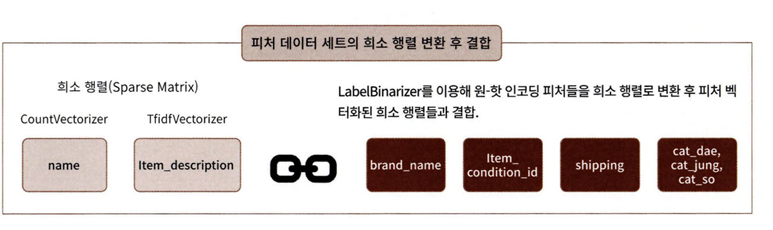

In [23]:
from sklearn.preprocessing import LabelBinarizer

# brand_name, item_condition_id, shipping 각 피처들을 희소행렬 원-핫 인코딩 변환
lb_brand_name= LabelBinarizer(sparse_output=True)
X_brand= lb_brand_name.fit_transform(mercari_df['brand_name'])
lb_item_cond_id= LabelBinarizer(sparse_output=True)
X_item_cond_id= lb_item_cond_id.fit_transform(mercari_df['item_condition_id'])
lb_shipping= LabelBinarizer(sparse_output=True)
X_shipping= lb_shipping.fit_transform(mercari_df['shipping'])

# cat_dae, cat_jung, cat_so 각 피처들을 희소 행렬 원-핫 인코딩 변환
lb_cat_dae= LabelBinarizer(sparse_output=True)
X_cat_dae= lb_cat_dae.fit_transform(mercari_df['cat_dae'])
lb_cat_jung = LabelBinarizer(sparse_output=True)
X_cat_jung = lb_cat_jung.fit_transform(mercari_df ['cat_jung'])
lb_cat_so = LabelBinarizer(sparse_output=True)
X_cat_so = lb_cat_so.fit_transform(mercari_df['cat_so'])

In [24]:
print(type(X_brand), type(X_item_cond_id), type(X_shipping))
print('X_brand shape:{0}, X_item_cond_id shape:{1}'.format(X_brand.shape, X_item_cond_id.shape))
print('X_shipping shape:{0}, X_cat_dae shape:{1}'.format(X_shipping.shape, X_cat_dae.shape))
print('X_cat_jung shape:{0}, X_cat_so shape:{1}'.format(X_cat_jung.shape, X_cat_so.shape))

<class 'scipy.sparse._csr.csr_matrix'> <class 'scipy.sparse._csr.csr_matrix'> <class 'scipy.sparse._csr.csr_matrix'>
X_brand shape:(1482535, 4810), X_item_cond_id shape:(1482535, 5)
X_shipping shape:(1482535, 1), X_cat_dae shape:(1482535, 11)
X_cat_jung shape:(1482535, 114), X_cat_so shape:(1482535, 871)


- 인코딩 변환된 데이터 세트가 CSR형태로 변환된 csr_matrix 타입임
- brand_name칼럼은 종류가 4810개여서 인코딩 후 4810개의 칼럼을 갖게 됨 -> 피처 벡터화로 텍스트 형태의 문자열이 갖는 벡터 형태의 매우 많은 칼럼과 결합될것이므로 문제없음
- 이제 hstack() 이용해 결합해보자

In [25]:
from scipy.sparse import hstack
import gc

sparse_matrix_list= (X_name, X_descp, X_brand, X_item_cond_id,\
                     X_shipping, X_cat_dae, X_cat_jung, X_cat_so)

# hstack 함수를 이용해 인코딩과 벡터화를 수행한 데이터 세트를 모두 결합
X_features_sparse= hstack(sparse_matrix_list).tocsr()
print(type(X_features_sparse), X_features_sparse.shape)

# 데이터 세트가 메모리를 많이 차지하므로 사용 목적이 끝났으면 바로 메모리에서 삭제
del X_features_sparse
gc.collect()

<class 'scipy.sparse._csr.csr_matrix'> (1482535, 161569)


455

- 결합된 데이터 세트는 csr_matrix 타입, 161509개 피처

**릿지 회귀 모델 구축 및 평가**
- 예측성능 비교할 예정 -> 필요한 로직 함수화하자
- 평가지표 : RMSLE 방식
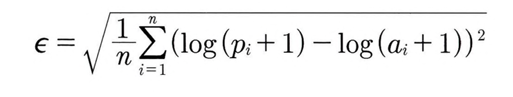

In [26]:
def rmsle(y, y_pred):
    # underflow, overflow를 막기 위해 log가 아닌 log1p로 rmsle 계산
    return np.sqrt(np.mean(np.power(np.log1p(y)-np.log1p(y_pred), 2)))

def evaluate_org_price(y_test, preds):
    #원본 데이터는 log1p로 변환되었으므로 exmpm1로 원복 필요
    preds_exmpm= np.expm1(preds)
    y_test_exmpm= np.expm1(y_test)

    #rmsle로 RMSLE값 추출
    rmsle_result= rmsle(y_test_exmpm, preds_exmpm)
    return rmsle_result

In [27]:
import gc
from scipy.sparse import hstack
from sklearn.model_selection import train_test_split

def model_train_predict(model, matrix_list):
    X = hstack(matrix_list).tocsr()
    y_target = mercari_df['price']

    X_train, X_test, y_train, y_test = train_test_split(X, y_target, test_size=0.2, random_state=156)

    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    del X, X_train, X_test, y_train
    gc.collect()

    return preds, y_test

Ridge 이용해서 회귀 예측수행하자
- 수행 전 item_description같은 텍스트 형태 속성이 미치는 영향 알아보자

In [28]:
linear_model = Ridge(solver="lsqr", fit_intercept=False)

sparse_matrix_list = [X_name, X_brand, X_item_cond_id,
                      X_shipping, X_cat_dae, X_cat_jung, X_cat_so]
linear_preds, y_test = model_train_predict(model=linear_model, matrix_list=sparse_matrix_list)
print('Item Description을 제외했을 때 rmsle 값:', evaluate_org_price(y_test, linear_preds))

sparse_matrix_list = [X_descp, X_name, X_brand, X_item_cond_id,
                      X_shipping, X_cat_dae, X_cat_jung, X_cat_so]
linear_preds, y_test = model_train_predict(model=linear_model, matrix_list=sparse_matrix_list)
print('Item Description을 포함한 rmsle 값:', evaluate_org_price(y_test, linear_preds))

Item Description을 제외했을 때 rmsle 값: 0.4983990938999374
Item Description을 포함한 rmsle 값: 0.4680432471796771


**LightGBM 회귀 모델 구축과 앙상블을 이용한 최종 예측 평가**
- 먼저 LGBM 으로 회귀 수행

In [ ]:
# from lightgbm import LGBMRegressor
# sparse_matrix_list = (X_descpz X_namez X_brand, X_item_cond_id,
# X_shipping, X_cat_dae, X_cat_jungz X_cat_so)
# lgbm_model = LGBMRegressor(n_estimators=200, learning_rate=0.5, num_leaves=125, random_state=156)
# lgbm_preds, y_test = model_train_predict(model = lgbm_model, matrix_list=sparse_matrix_list)
# print('LightGBM rmsle 값:,, evaluate_org_price(y_test, Igbm_preds))

In [ ]:
# preds = lgbm_preds * 0.45 + linearjoreds * 0.55
# print(‘LightGBM과 Ridge를 ensemble한 최종 rmsle 값:,, evaluate_org_price(y_test, preds))